<a href="https://www.kaggle.com/code/sonawanelalitsunil/predicting-road-accident-risk-eda?scriptVersionId=264995367" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
import warnings, os, gc, sys, math, json, random, itertools
from scipy import stats
from scipy.stats import ks_2samp
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


## Title:
🚦 Predicting Road Accident Risk

## Description:
This project focuses on analyzing traffic, weather, and road conditions to build predictive models that estimate the likelihood of road accidents. By applying machine learning and data-driven insights, it aims to identify high-risk factors such as vehicle density, time of day, road type, and driver behavior. The goal is to provide proactive risk assessments that can help city planners, traffic authorities, and insurance companies enhance road safety, reduce accident frequency, and support smarter decision-making.

## Import dataset

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')
sub = pd.read_csv('/kaggle/input/playground-series-s5e10/sample_submission.csv')

In [3]:
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
train.tail()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51
517753,517753,highway,2,0.31,45,dim,rainy,False,True,afternoon,True,True,2,0.22


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [6]:
train.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [7]:
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [8]:
train.duplicated().sum()

0

In [9]:
train.nunique()

id                        517754
road_type                      3
num_lanes                      4
curvature                    261
speed_limit                    5
lighting                       3
weather                        3
road_signs_present             2
public_road                    2
time_of_day                    3
holiday                        2
school_season                  2
num_reported_accidents         8
accident_risk                 98
dtype: int64

In [10]:
train.describe().loc[['mean','min','max']].T

,mean,min,max
id,258876.500000,0.0,517753.0
num_lanes,2.491511,1.0,4.0
curvature,0.488719,0.0,1.0
speed_limit,46.112575,25.0,70.0
num_reported_accidents,1.187970,0.0,7.0
accident_risk,0.352377,0.0,1.0


In [11]:
train['accident_risk'].value_counts()

accident_risk
0.34    15542
0.32    14240
0.37    13453
0.28    13287
0.39    12499
        ...  
0.94       47
0.97       28
0.96       28
0.90       26
0.93       23
Name: count, Length: 98, dtype: int64

In [12]:
cat_cols = ['road_type','lighting','weather','road_signs_present','public_road','time_of_day','holiday','school_season']
num_cols = ['num_lanes','curvature','speed_limit','num_reported_accidents']
target = 'accident_risk'
train['accident_risk_bins']=train[target]
#Binning the target to make it easier to visualize
train['accident_risk_bins'] = pd.cut(
    train[target],
    bins=[0, 0.25, 0.5, 0.75, 1],
    labels=["Q1", "Q2", "Q3", "Q4"],
    include_lowest=True
)

In [13]:
def quick_overview(df, name):
    print(f"\n{name.upper()} SHAPE: {df.shape}")
    display(df.head())
    display(df.describe(include="all").T)

In [14]:
quick_overview(train, "train")
quick_overview(test , "test")


TRAIN SHAPE: (517754, 15)


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,accident_risk_bins
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,Q1
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,Q2
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,Q2
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,Q1
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,Q3


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,517754.0,NaN,NaN,NaN,258876.5,149462.849974,0.0,129438.25,258876.5,388314.75,517753.0
road_type,517754,3,highway,173672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_lanes,517754.0,NaN,NaN,NaN,2.491511,1.120434,1.0,1.0,2.0,3.0,4.0
curvature,517754.0,NaN,NaN,NaN,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0
speed_limit,517754.0,NaN,NaN,NaN,46.112575,15.788521,25.0,35.0,45.0,60.0,70.0
lighting,517754,3,dim,183826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,517754,3,foggy,181463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_signs_present,517754,2,False,259289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
public_road,517754,2,True,260045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,517754,3,morning,173410,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TEST SHAPE: (172585, 13)


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,172585.0,NaN,NaN,NaN,604046.0,49821.142441,517754.0,560900.0,604046.0,647192.0,690338.0
road_type,172585,3,highway,58080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_lanes,172585.0,NaN,NaN,NaN,2.494046,1.119148,1.0,1.0,2.0,3.0,4.0
curvature,172585.0,NaN,NaN,NaN,0.487263,0.272343,0.0,0.26,0.51,0.71,1.0
speed_limit,172585.0,NaN,NaN,NaN,46.102761,15.787077,25.0,35.0,45.0,60.0,70.0
lighting,172585,3,dim,61143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,172585,3,foggy,60236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_signs_present,172585,2,False,87093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
public_road,172585,2,True,86673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,172585,3,morning,57747,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print(f"Duplicate rows (train): {train.duplicated().sum()}  |  (test): {test.duplicated().sum()}")

Duplicate rows (train): 0  |  (test): 0


In [16]:
train.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk',
       'accident_risk_bins'],
      dtype='object')

## Data visualizations

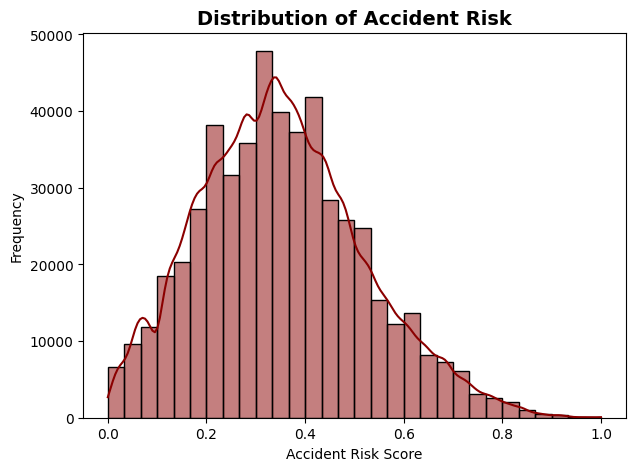

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(train['accident_risk'], kde=True, bins=30, color="darkred")
plt.title("Distribution of Accident Risk", fontsize=14, fontweight="bold")
plt.xlabel("Accident Risk Score")
plt.ylabel("Frequency")
plt.show()

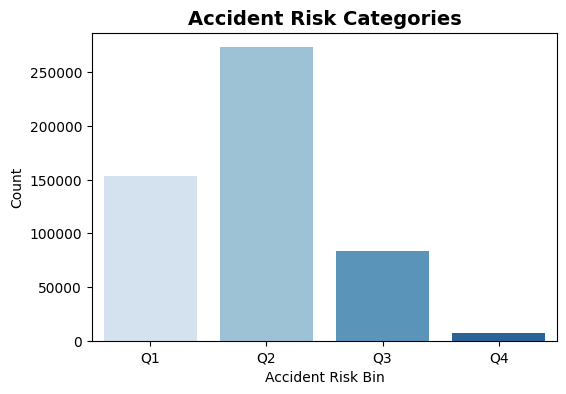

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='accident_risk_bins', data=train, palette="Blues")
plt.title("Accident Risk Categories", fontsize=14, fontweight="bold")
plt.xlabel("Accident Risk Bin")
plt.ylabel("Count")
plt.show()

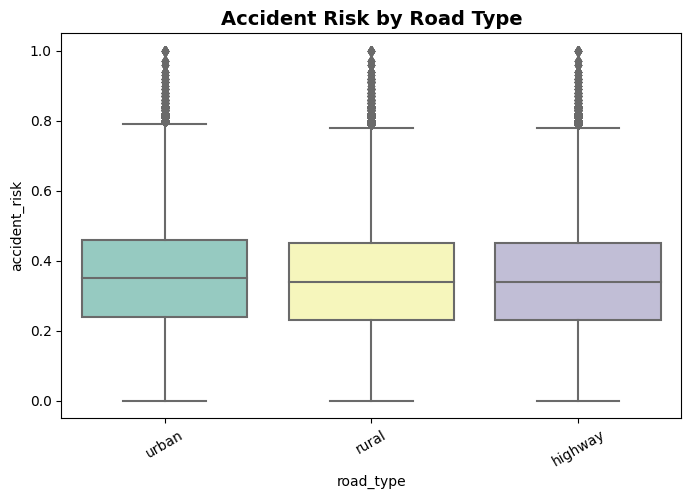

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="road_type", y="accident_risk", data=train, palette="Set3")
plt.title("Accident Risk by Road Type", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.show()

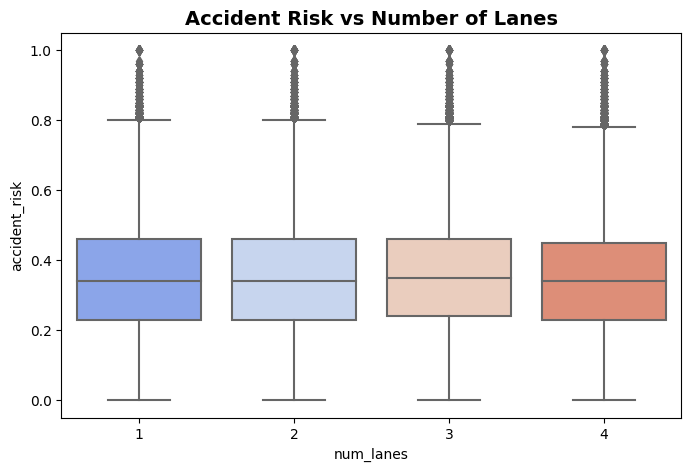

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="num_lanes", y="accident_risk", data=train, palette="coolwarm")
plt.title("Accident Risk vs Number of Lanes", fontsize=14, fontweight="bold")
plt.show()

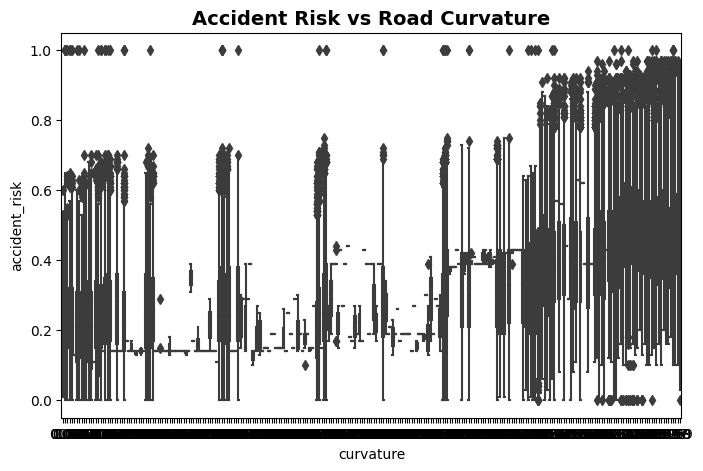

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="curvature", y="accident_risk", data=train, palette="muted")
plt.title("Accident Risk vs Road Curvature", fontsize=14, fontweight="bold")
plt.show()

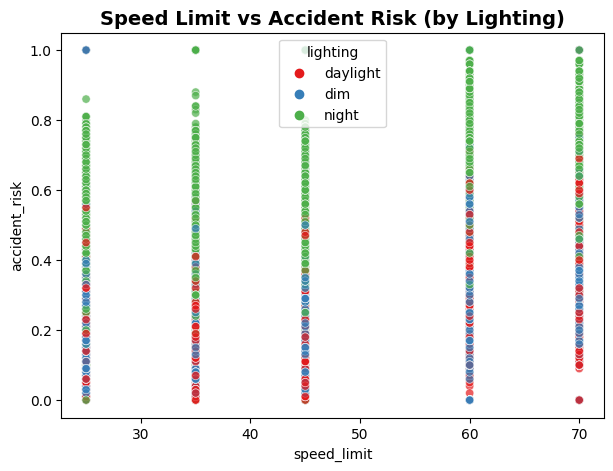

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="speed_limit", y="accident_risk", hue="lighting", data=train, palette="Set1", alpha=0.7)
plt.title("Speed Limit vs Accident Risk (by Lighting)", fontsize=14, fontweight="bold")
plt.show()

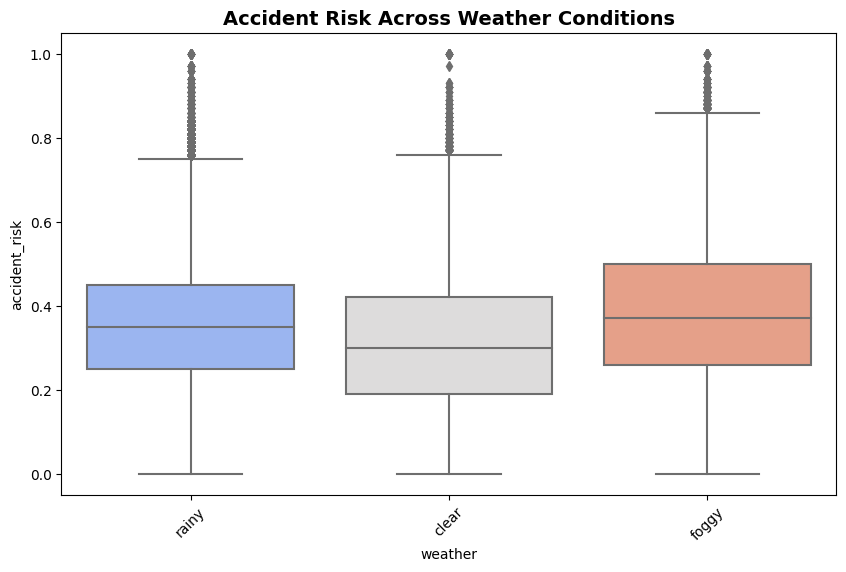

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x="weather", y="accident_risk", data=train, palette="coolwarm")
plt.title("Accident Risk Across Weather Conditions", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

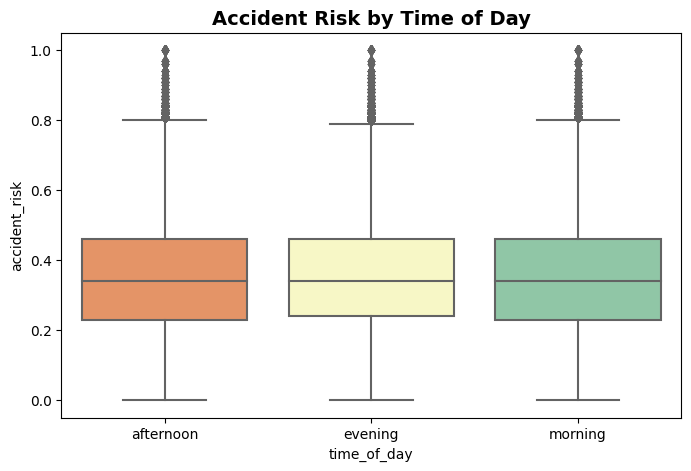

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="time_of_day", y="accident_risk", data=train, palette="Spectral")
plt.title("Accident Risk by Time of Day", fontsize=14, fontweight="bold")
plt.show()


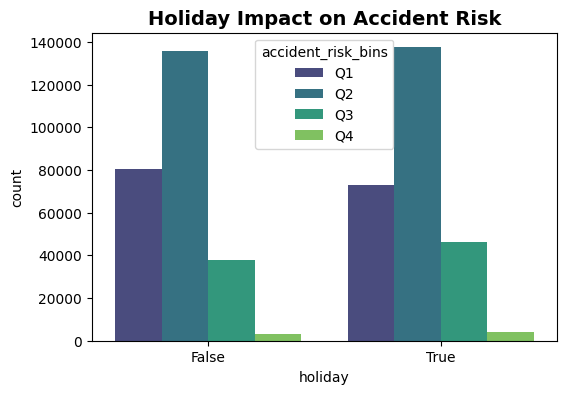

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="holiday", hue="accident_risk_bins", data=train, palette="viridis")
plt.title("Holiday Impact on Accident Risk", fontsize=14, fontweight="bold")
plt.show()


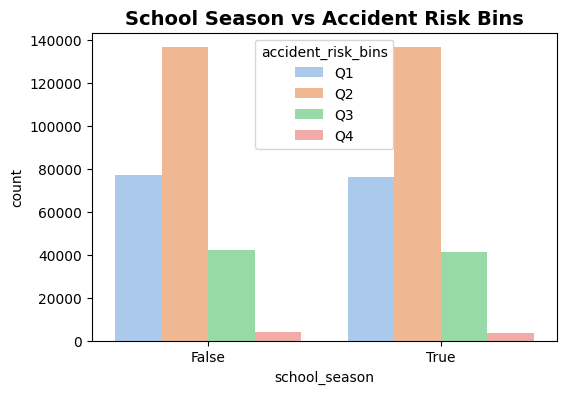

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="school_season", hue="accident_risk_bins", data=train, palette="pastel")
plt.title("School Season vs Accident Risk Bins", fontsize=14, fontweight="bold")
plt.show()

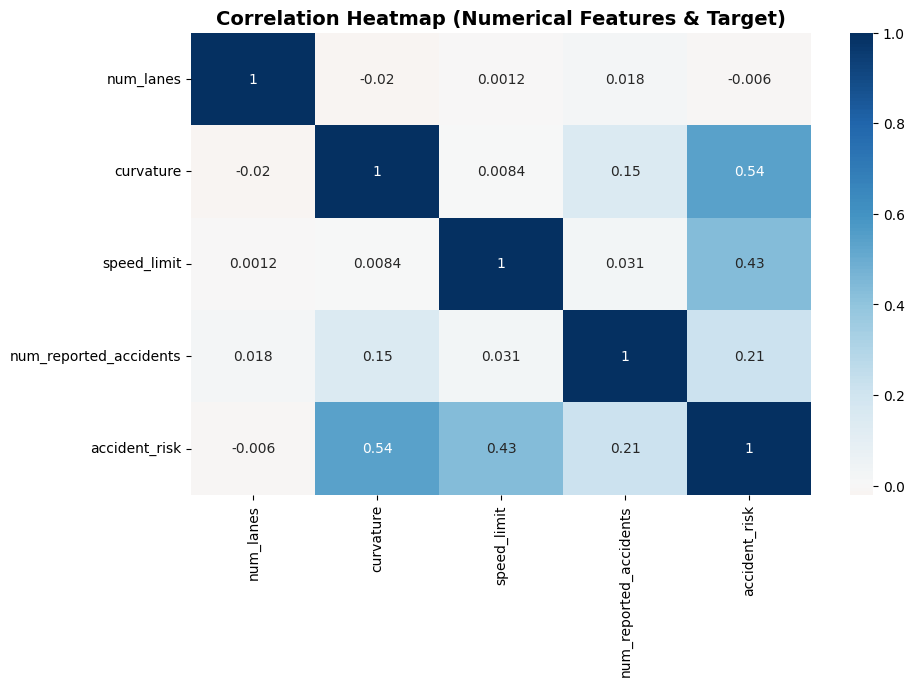

In [27]:
plt.figure(figsize=(10,6))
corr = train[['num_lanes','curvature','speed_limit','num_reported_accidents','accident_risk']].corr()
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap (Numerical Features & Target)", fontsize=14, fontweight="bold")
plt.show()

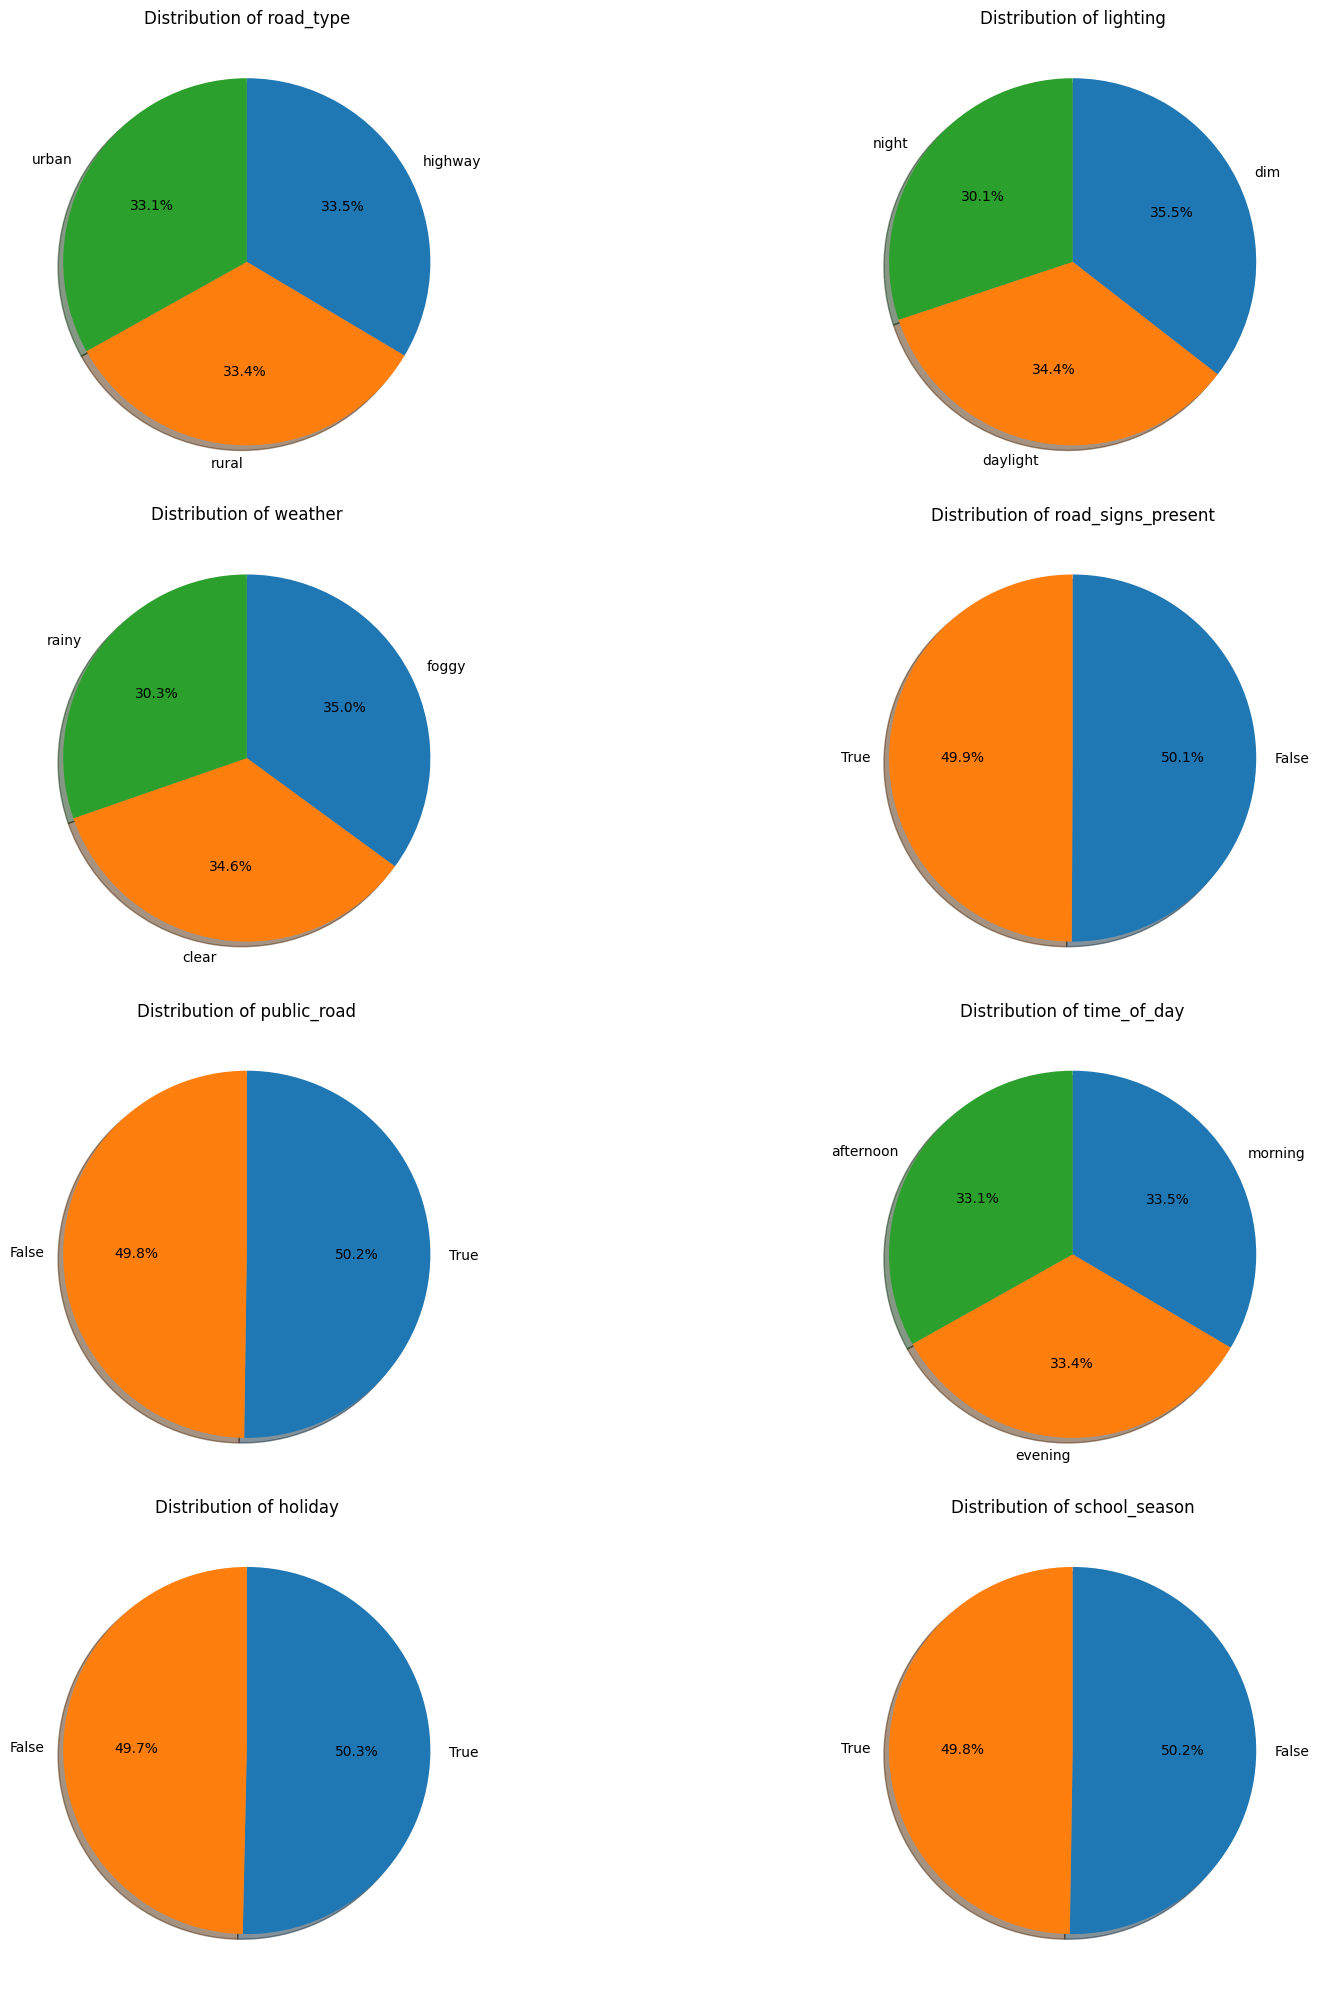

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    train[col].value_counts().plot.pie(
        ax=axes[i],
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        shadow=True
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("")  # Remove y-label for cleaner plot

plt.tight_layout()
plt.show()

In [29]:
numerical_cols = ['id', 'num_lanes', 'curvature', 'num_reported_accidents', 'speed_limit', 'accident_risk']

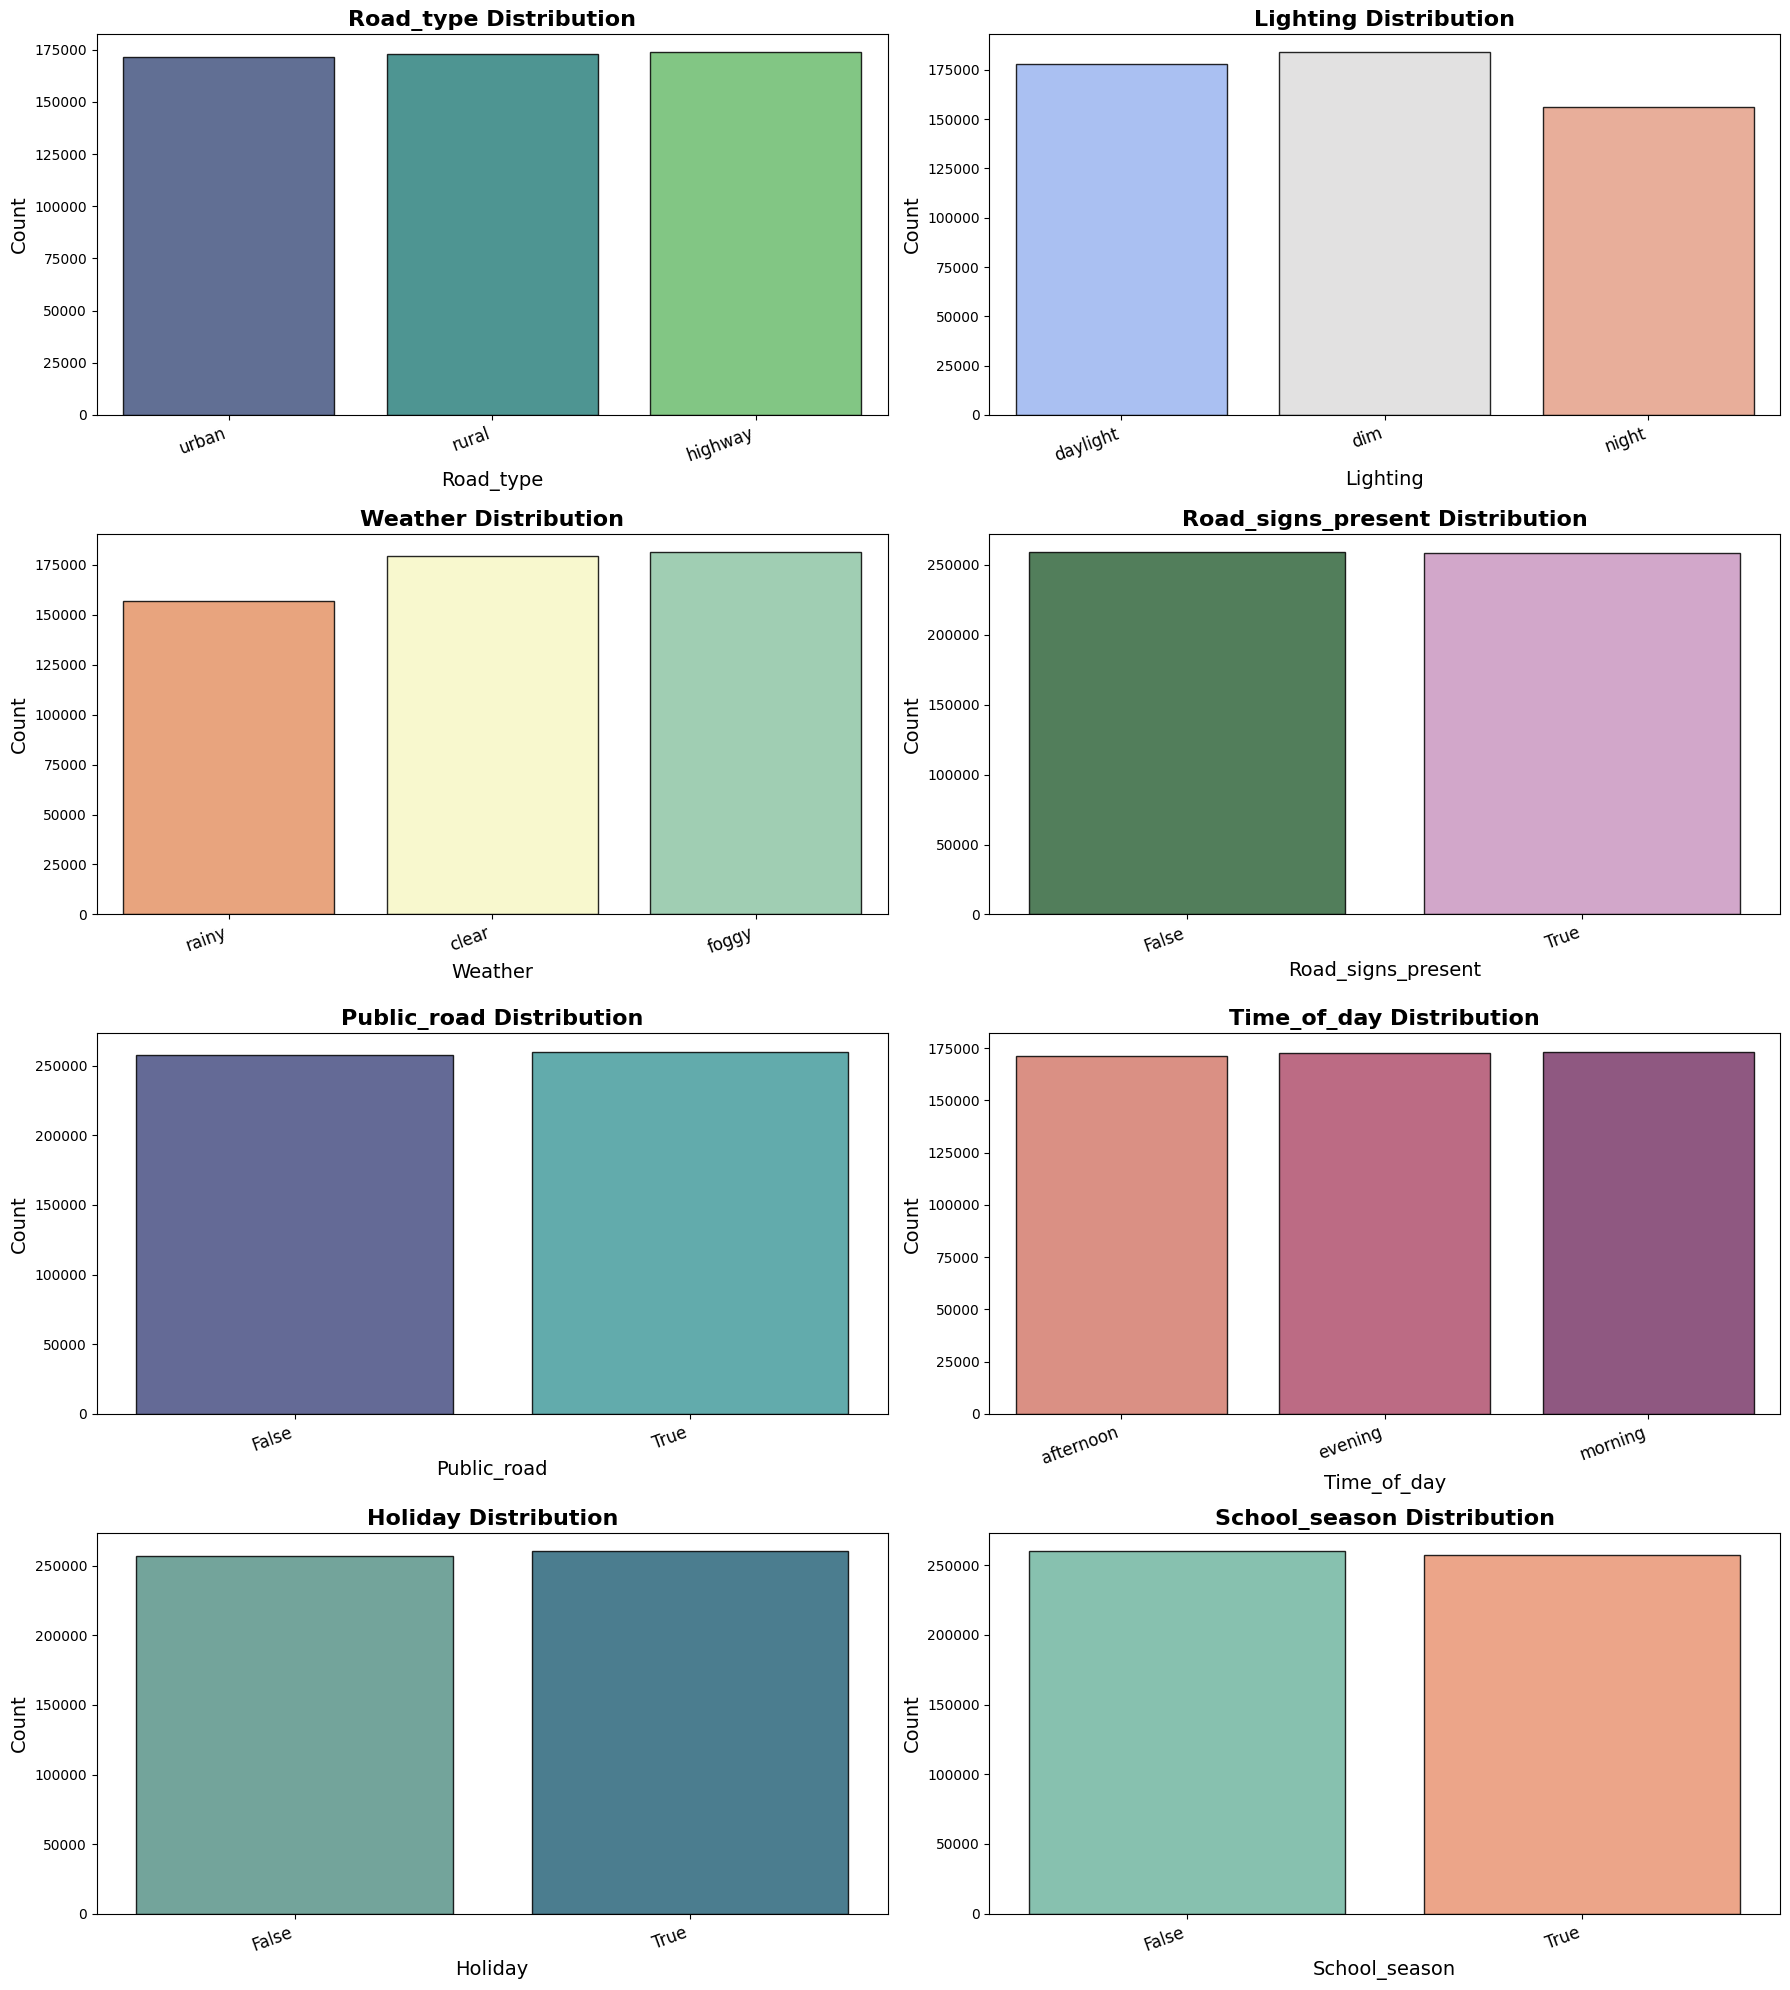

In [30]:
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Define different palettes for uniqueness
palettes = ["viridis", "coolwarm", "Spectral", "cubehelix", 
            "mako", "flare", "crest", "Set2", "Set3", "Paired"]

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(
        data=train, 
        x=col, 
        ax=ax, 
        palette=palettes[i % len(palettes)],   # cycle through palettes
        edgecolor="black",                     # border for bars
        alpha=0.85                             # transparency
    )
    ax.set_title(f"{col.capitalize()} Distribution", fontsize=16, fontweight="bold")
    ax.set_xlabel(col.capitalize(), fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=12)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

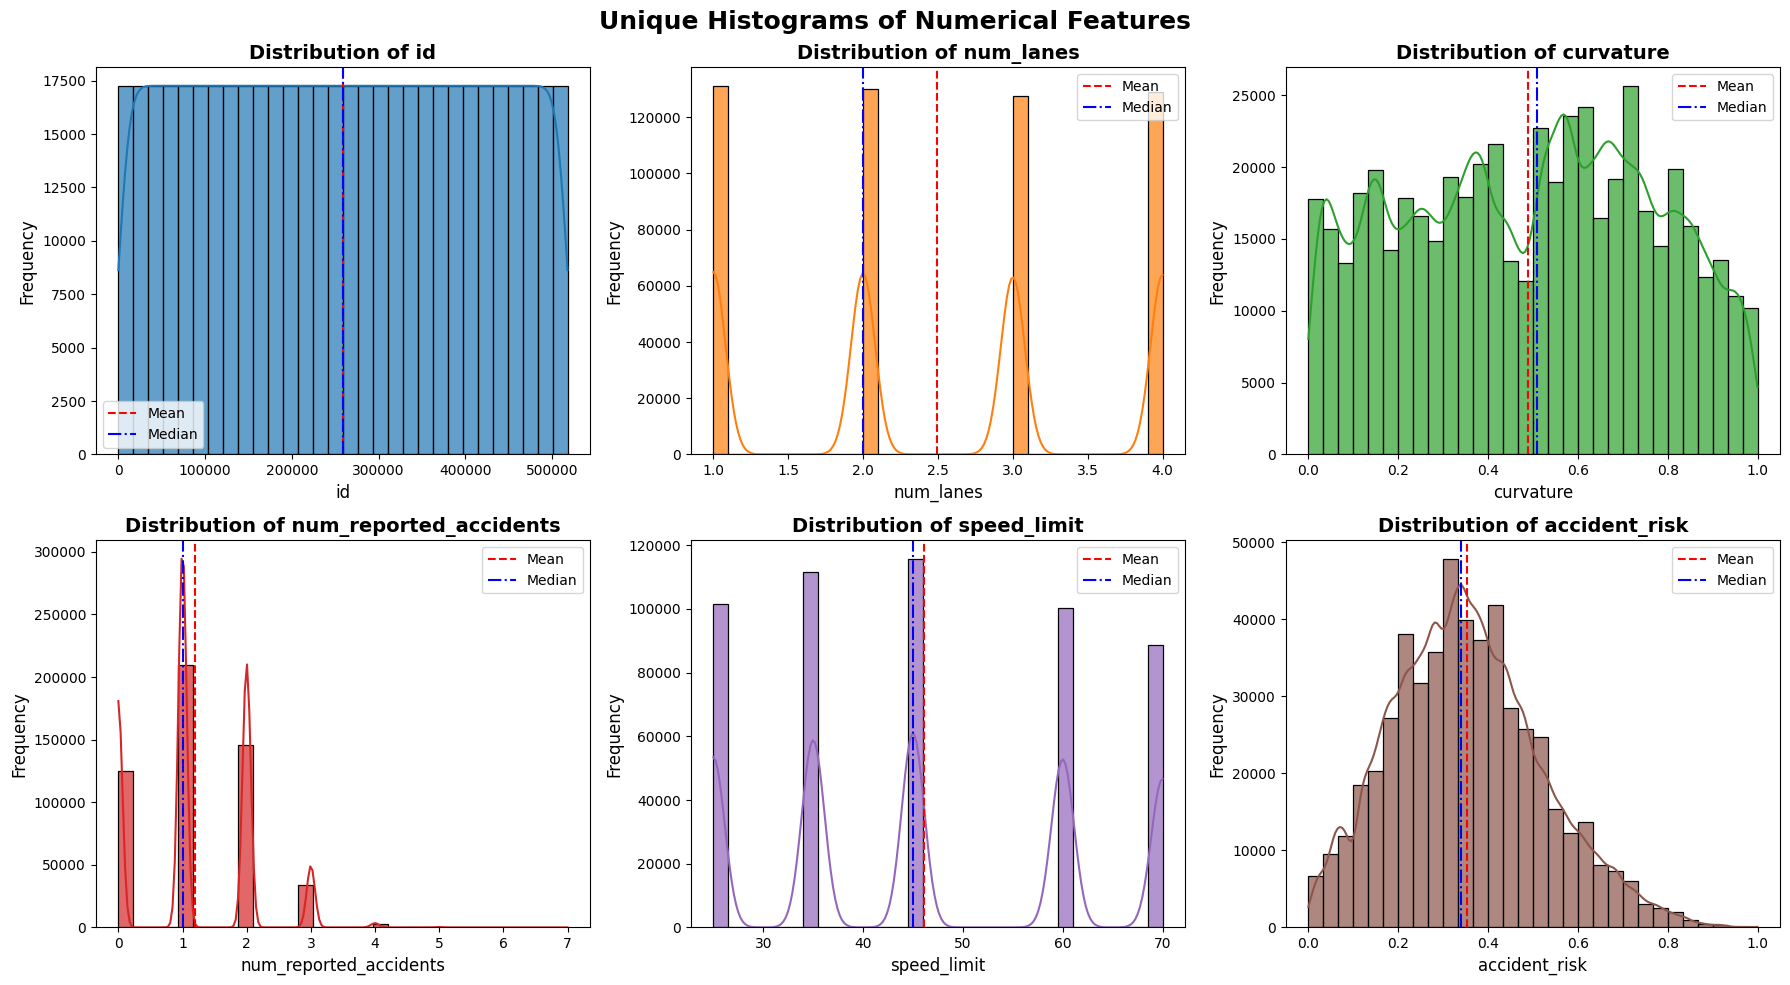

In [31]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", 
          "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", 
          "#bcbd22", "#17becf"]
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    color = colors[i % len(colors)]  # cycle colors
    
    # Histogram with KDE
    sns.histplot(train[col], bins=30, kde=True, ax=ax, color=color, edgecolor="black", alpha=0.7)
    
    # Mean & Median lines
    ax.axvline(train[col].mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
    ax.axvline(train[col].median(), color="blue", linestyle="-.", linewidth=1.5, label="Median")
    
    # Title & labels
    ax.set_title(f"Distribution of {col}", fontsize=14, fontweight="bold")
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.legend()

# Remove extra empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Unique Histograms of Numerical Features", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [32]:
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(train[col].value_counts(normalize=True).rename("proportion"))

<Figure size 640x480 with 0 Axes>

road_type
highway    0.335433
rural      0.333593
urban      0.330974
Name: proportion, dtype: float64
lighting
dim         0.355045
daylight    0.343822
night       0.301133
Name: proportion, dtype: float64
weather
foggy    0.350481
clear    0.346315
rainy    0.303204
Name: proportion, dtype: float64
road_signs_present
False    0.500796
True     0.499204
Name: proportion, dtype: float64
public_road
True     0.502256
False    0.497744
Name: proportion, dtype: float64
time_of_day
morning      0.334927
evening      0.333821
afternoon    0.331252
Name: proportion, dtype: float64
holiday
True     0.503498
False    0.496502
Name: proportion, dtype: float64
school_season
False    0.502486
True     0.497514
Name: proportion, dtype: float64


In [33]:
for col in cat_cols:
    print(train.groupby(col)["accident_risk"].mean())

road_type
highway    0.349734
rural      0.349997
urban      0.357456
Name: accident_risk, dtype: float64
lighting
daylight    0.302923
dim         0.300109
night       0.470467
Name: accident_risk, dtype: float64
weather
clear    0.310060
foggy    0.386305
rainy    0.361494
Name: accident_risk, dtype: float64
road_signs_present
False    0.352273
True     0.352482
Name: accident_risk, dtype: float64
public_road
False    0.347190
True     0.357518
Name: accident_risk, dtype: float64
time_of_day
afternoon    0.351428
evening      0.354736
morning      0.350966
Name: accident_risk, dtype: float64
holiday
False    0.343809
True     0.360827
Name: accident_risk, dtype: float64
school_season
False    0.352539
True     0.352214
Name: accident_risk, dtype: float64


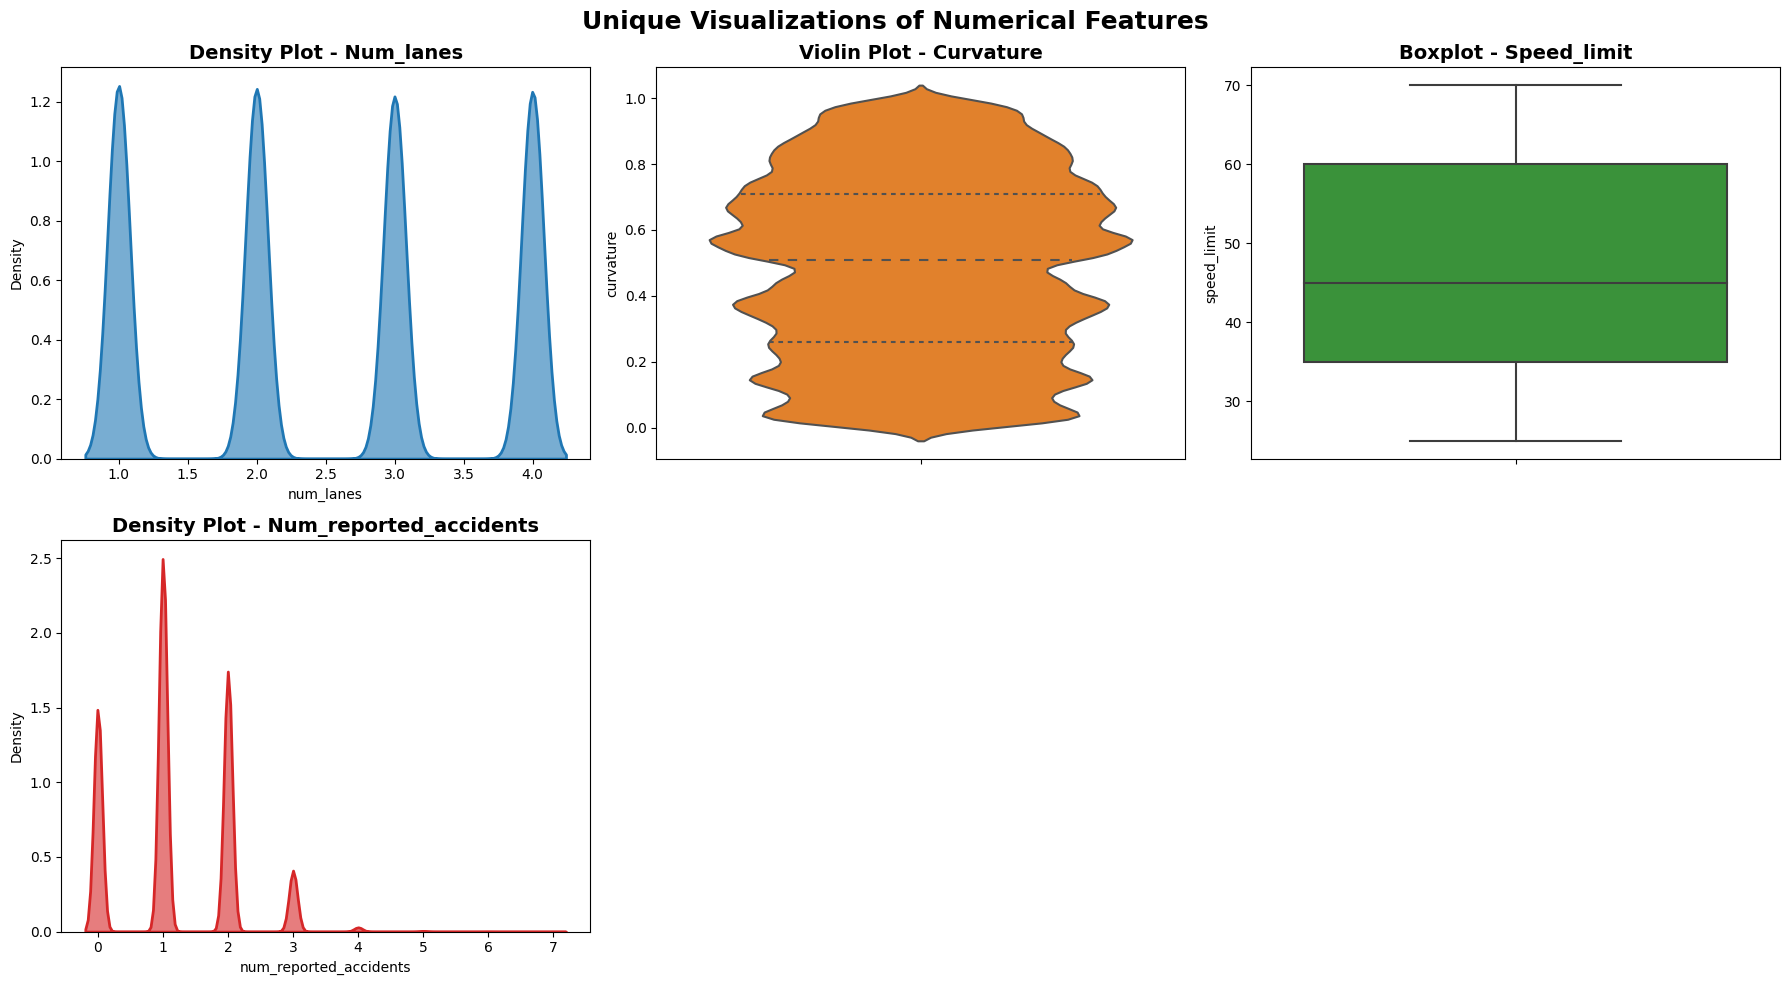

In [34]:
import math
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Cycle of unique colors
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
          "#bcbd22", "#17becf"]

for i, col in enumerate(num_cols):
    ax = axes[i]
    color = colors[i % len(colors)]

    # Use different plot types based on feature
    if col == 'curvature':
        sns.violinplot(y=train[col], ax=ax, color=color, inner="quartile")
        ax.set_title(f"Violin Plot - {col.capitalize()}", fontsize=14, fontweight="bold")
        ax.set_ylabel(col)

    elif col == 'speed_limit':
        sns.boxplot(y=train[col], ax=ax, color=color)
        ax.set_title(f"Boxplot - {col.capitalize()}", fontsize=14, fontweight="bold")
        ax.set_ylabel(col)

    else:
        sns.kdeplot(train[col], ax=ax, fill=True, color=color, alpha=0.6, linewidth=2)
        ax.set_title(f"Density Plot - {col.capitalize()}", fontsize=14, fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Unique Visualizations of Numerical Features", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [35]:
outlier_summary = {}
for col in num_cols:
    z = np.abs(stats.zscore(train[col].dropna()))
    outlier_summary[col] = (z > 3).sum()  
outlier_df = pd.Series(outlier_summary, name="# Outliers (>3σ)") \
                .sort_values(ascending=False).to_frame()
outlier_df.style.bar(color='lightcoral', align='mid')

,# Outliers (>3σ)
num_reported_accidents,2649
num_lanes,0
curvature,0
speed_limit,0


## Data modeling

In [36]:
from itertools import combinations

In [37]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import gc
import optuna
import copy

In [38]:
cat_cols = ['road_type','lighting','weather','road_signs_present','public_road','time_of_day','holiday','school_season']
num_cols = ['num_lanes','curvature','speed_limit','num_reported_accidents']
target = 'accident_risk'

In [39]:
new_cat_cols = []

In [40]:
for col1, col2 in combinations(cat_cols, 2):
    new_col = f"{col1}_{col2}"
    train[new_col] = train[col1].astype(str) + "_" + train[col2].astype(str)
    test[new_col] = test[col1].astype(str) + "_" + test[col2].astype(str)
    new_cat_cols.append(new_col)

In [41]:
for i in range(len(num_cols)):
    for j in range(i, len(num_cols)):
        col1 = num_cols[i]
        col2 = num_cols[j]
        # Multiplication
        train[f'{col1}_x_{col2}'] = train[col1] * train[col2]
        test[f'{col1}_x_{col2}'] = test[col1] * test[col2]
        # Squared
        train[f'{col1}_squared'] = train[col1]**2
        test[f'{col1}_squared'] = test[col1]**2
        # Ratio (avoid division by zero)
        if col1 != col2:
            train[f'{col1}_div_{col2}'] = train[col1] / (train[col2] + 1e-6)
            test[f'{col1}_div_{col2}'] = test[col1] / (test[col2] + 1e-6)

In [42]:
for col in cat_cols + new_cat_cols:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

In [43]:
X = train.drop(columns=['id', target])
y = train[target]
X_test = test.drop(columns=['id'])

In [44]:
extra_cols = [c for c in X.columns if c not in X_test.columns]
X = X.drop(columns=extra_cols)
X_test = X_test[X.columns]

In [45]:
xgb_params = {
    'n_estimators': 1000,         
    'max_leaves': 211,            
    'min_child_weight': 1.5,     
    'max_depth': 12,               
    'grow_policy': 'lossguide',   
    'learning_rate': 0.02,      
    'tree_method': 'hist',        
    'subsample': 0.85,            
    'colsample_bylevel': 0.6787,     
    'colsample_bytree': 0.6844,       
    'colsample_bynode': 0.4421,     
    'sampling_method': 'uniform',  
    'reg_alpha': 2.5,             
    'reg_lambda': 0.8,            
    'enable_categorical': True,    
    'max_cat_to_onehot': 1,       
    'device': 'cuda',            
    'n_jobs': -1,                 
    'random_state': 42,     
    'verbosity': 0,               
}

In [46]:
lgbm_params = {
    'learning_rate': 0.04,
    'num_leaves': 79, 
    'max_depth': 12,
    'feature_fraction': 0.8933,
    'bagging_fraction': 0.9754,
    'bagging_freq': 7, 
    'min_child_samples': 40,
    'enable_categorical': True,   
    'lambda_l1': 7.11e-07,
    'lambda_l2': 7.82e-08,
    'random_state' : 42,
    'n_jobs' : -1,
    'verbosity': -1,
    'n_estimators': 1000
}

In [47]:
print('Training XGBoost...')
xgb_model = XGBRegressor(**xgb_params)
xgb_oof_preds = np.zeros(len(X))
xgb_models, xgb_scores = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Fold {fold+1}')
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_model.fit(X_train, y_train)
    preds_val = xgb_model.predict(X_val)
    
    xgb_oof_preds[val_idx] = preds_val
    score = mean_squared_error(y_val, preds_val, squared=False)
    xgb_scores.append(score)
    xgb_models.append(copy.deepcopy(xgb_model))
    print('Fold RMSE:', score)

print('XGB Mean RMSE:', np.mean(xgb_scores))

Training XGBoost...
Fold 1
Fold RMSE: 0.056314377885146066
Fold 2
Fold RMSE: 0.05617236612055801
Fold 3
Fold RMSE: 0.0562096991520131
Fold 4
Fold RMSE: 0.0560466869788737
Fold 5
Fold RMSE: 0.05599984666887964
XGB Mean RMSE: 0.0561485953610941


In [48]:
print('Training LightGBM...')
lgbm_model = LGBMRegressor(**lgbm_params)
lgbm_oof_preds = np.zeros(len(X))
lgbm_models, lgbm_scores = [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'Fold {fold+1}')
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgbm_model.fit(X_train, y_train)
    preds_val = lgbm_model.predict(X_val)
    
    lgbm_oof_preds[val_idx] = preds_val
    score = mean_squared_error(y_val, preds_val, squared=False)
    lgbm_scores.append(score)
    lgbm_models.append(copy.deepcopy(lgbm_model))
    print('Fold RMSE:', score)

print('LGBM Mean RMSE:', np.mean(lgbm_scores))

Training LightGBM...
Fold 1
Fold RMSE: 0.05635357542121548
Fold 2
Fold RMSE: 0.05622144708988337
Fold 3
Fold RMSE: 0.0562381180398067
Fold 4
Fold RMSE: 0.0560807585314447
Fold 5
Fold RMSE: 0.05607111046804303
LGBM Mean RMSE: 0.05619300191007866


In [49]:
print("LGBM Mean RMSE:", np.mean(lgbm_scores))

# --- STACKING FOR ENSEMBLE ---
X_stack = pd.DataFrame({'xgb': xgb_oof_preds, 'lgbm': lgbm_oof_preds})

xgb_test_preds = np.mean([model.predict(X_test) for model in xgb_models], axis=0)
lgbm_test_preds = np.mean([model.predict(X_test) for model in lgbm_models], axis=0)

LGBM Mean RMSE: 0.05619300191007866


In [50]:
def objective(trial):
    w_lgbm = trial.suggest_float("w_lgbm", 0, 1)
    w_xgb = 1 - w_lgbm
    final_preds = w_lgbm * X_stack['lgbm'] + w_xgb * X_stack['xgb']
    score = mean_squared_error(y, final_preds, squared=False)
    return score

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)  # reduced for speed
print("Best RMSE:", study.best_value)
print("Best Weight:", study.best_params)

[I 2025-10-01 05:14:39,118] A new study created in memory with name: no-name-2a45a801-ec3e-430b-a479-299ff3659bab
[I 2025-10-01 05:14:39,129] Trial 0 finished with value: 0.05618518744010085 and parameters: {'w_lgbm': 0.9644117365755891}. Best is trial 0 with value: 0.05618518744010085.
[I 2025-10-01 05:14:39,137] Trial 1 finished with value: 0.05612991729605333 and parameters: {'w_lgbm': 0.5859888473610798}. Best is trial 1 with value: 0.05612991729605333.
[I 2025-10-01 05:14:39,144] Trial 2 finished with value: 0.056122062082351334 and parameters: {'w_lgbm': 0.38282421940951183}. Best is trial 2 with value: 0.056122062082351334.
[I 2025-10-01 05:14:39,152] Trial 3 finished with value: 0.05617863935315557 and parameters: {'w_lgbm': 0.9332446529870596}. Best is trial 2 with value: 0.056122062082351334.
[I 2025-10-01 05:14:39,158] Trial 4 finished with value: 0.056131725859831914 and parameters: {'w_lgbm': 0.15108500833709393}. Best is trial 2 with value: 0.056122062082351334.
[I 2025-1

Best RMSE: 0.05612206038453877
Best Weight: {'w_lgbm': 0.37993043230401885}


In [51]:
w_lgbm = study.best_params['w_lgbm']
w_xgb = 1 - w_lgbm
final_preds = w_lgbm * lgbm_test_preds + w_xgb * xgb_test_preds

submission = pd.DataFrame({'id': test['id'], 'accident_risk': final_preds})
submission.to_csv('submission.csv', index=False)
submission.head()

,id,accident_risk
0,517754,0.297925
1,517755,0.119918
2,517756,0.181625
3,517757,0.315428
4,517758,0.402745


## Thank you..pls upvote!!!!